**Imports and load data**

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../Dataset/telco_churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

**Prepare features**

In [2]:
df_model = df.drop(columns=['customerID'])
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

**Check and visualize class balance**

Churn
0    5163
1    1869
Name: count, dtype: int64
Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


C:\Users\ha626\AppData\Local\Temp\ipykernel_11792\2229677522.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_model, x='Churn', palette='Set2')


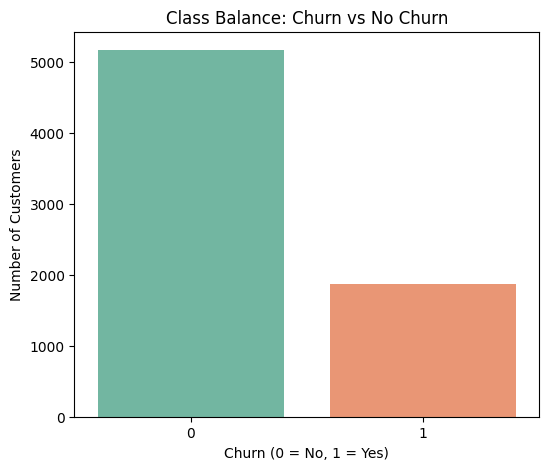

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

churn_counts = df_model['Churn'].value_counts()
churn_pct = df_model['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print(churn_pct)

plt.figure(figsize=(6, 5))
sns.countplot(data=df_model, x='Churn', palette='Set2')
plt.title('Class Balance: Churn vs No Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.show()

**Split the data**

In [4]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Train the "before" model (no imbalance handling)**

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

model_before = LogisticRegression(max_iter=1000)
model_before.fit(X_train, y_train)
y_pred_before = model_before.predict(X_test)

print("BEFORE (no imbalance handling):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_before):.4f}")
print(classification_report(y_test, y_pred_before, target_names=['No Churn', 'Churn']))

BEFORE (no imbalance handling):
Accuracy: 0.8031
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



d:\NeuroFive Internship\venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Apply SMOTE and retrain**

In [6]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

Before SMOTE: {0: 4130, 1: 1495}
After SMOTE: {0: 4130, 1: 4130}


**Retrain on the balanced data**

In [7]:
model_smote = LogisticRegression(max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = model_smote.predict(X_test)

print("AFTER SMOTE:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_smote):.4f}")
print(classification_report(y_test, y_pred_smote, target_names=['No Churn', 'Churn']))

AFTER SMOTE:
Accuracy: 0.7598
              precision    recall  f1-score   support

    No Churn       0.86      0.80      0.83      1033
       Churn       0.54      0.64      0.59       374

    accuracy                           0.76      1407
   macro avg       0.70      0.72      0.71      1407
weighted avg       0.78      0.76      0.77      1407



d:\NeuroFive Internship\venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**class_weight='balanced' for comparison**

In [8]:
model_weighted = LogisticRegression(max_iter=1000, class_weight='balanced')
model_weighted.fit(X_train, y_train)
y_pred_weighted = model_weighted.predict(X_test)

print("AFTER class_weight='balanced':")
print(f"Accuracy: {accuracy_score(y_test, y_pred_weighted):.4f}")
print(classification_report(y_test, y_pred_weighted, target_names=['No Churn', 'Churn']))

AFTER class_weight='balanced':
Accuracy: 0.7271
              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1033
       Churn       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



d:\NeuroFive Internship\venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Before/after comparison table**

In [9]:
comparison = pd.DataFrame({
    'Approach': ['Before (Baseline)', 'After SMOTE', 'After class_weight=balanced'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_before),
        accuracy_score(y_test, y_pred_smote),
        accuracy_score(y_test, y_pred_weighted)
    ],
    'Precision (Churn)': [
        precision_score(y_test, y_pred_before),
        precision_score(y_test, y_pred_smote),
        precision_score(y_test, y_pred_weighted)
    ],
    'Recall (Churn)': [
        recall_score(y_test, y_pred_before),
        recall_score(y_test, y_pred_smote),
        recall_score(y_test, y_pred_weighted)
    ],
    'F1-score (Churn)': [
        f1_score(y_test, y_pred_before),
        f1_score(y_test, y_pred_smote),
        f1_score(y_test, y_pred_weighted)
    ]
})
comparison

,Approach,Accuracy,Precision (Churn),Recall (Churn),F1-score (Churn)
0,Before (Baseline),0.803127,0.645646,0.574866,0.608204
1,After SMOTE,0.759773,0.540724,0.639037,0.585784
2,After class_weight=balanced,0.727079,0.491722,0.794118,0.607362


## Why Accuracy Alone Is Misleading Here

With roughly 73% of customers not churning, a model could predict 
"No Churn" for every single customer and still achieve about 73% 
accuracy — while being completely useless for the actual business 
goal of identifying at-risk customers. Accuracy treats every correct 
prediction equally, but in this problem the cost of missing a real 
churner (a false negative) is much higher than the cost of a false 
alarm, since a missed churner represents lost revenue the business 
never gets a chance to try to retain. This is why Recall on the 
"Churn" class matters more here than overall accuracy: it directly 
measures how many actual churners the model successfully catches, 
which is the metric that reflects real business value.